In [ ]:
# --- Libraries ---
import os
import numpy as np
from scipy.constants import e, m_e, hbar, pi
import matplotlib.pyplot as plt

In [ ]:
# --- physical constants ---
q = -e                              # electron charge (C)
m = m_e                             # electron mass (kg)
# --- external fields ---
B0 = 0.02                           # Glaser field magnetic strength (T)
wm = (2*hbar/abs(q*B0))**0.5        # magnetic width (m)
lB = (hbar/abs(q*B0))**0.5          # magnetic length (m)
tc = 2*pi*m/abs(q*B0)               # cyclotron period (s)
d0 = 160*wm#3.1623e-6               # Glaser field magnetic distance (m), Glaser field turns to uniform if d0 = np.inf
zc = 0.0e-6                         # Glaser field magnetic centroid (m)
# --- twisted electron (Landau state) ---
n, ell = 0, +3                      # radial and azimuthal quanta
wr = 2.0*wm                         # radical wave width (m)
px, py, pz = 0, 0, m*(160*wm)/(6*tc)# initial momentum (kg.m/s)
xp, yp, zp = 0, +6.0*wm, -80.0*wm   # initial position (m)
wz = 4.0*wm                         # longitudinal width (m)
# --- numerical settings ---
Nx, Ny, Nz = 200, 400, 1000         # grid resolution
Lx, Ly, Lz = 20*wm, 40*wm, 200*wm   # domain size (m)
dx, dy, dz = Lx/Nx, Ly/Ny, Lz/Nz    # grid spacing (m)
Nt = int(100)                       # number of time steps
dt = (6*tc)/Nt                      # time step (s)
Lt = Nt * dt                        # total simulation time (s)

In [ ]:
# --- Discrete spaces ---
x0, y0, z0 = -Lx/2, -Ly/2, -Lz/2                    # beginnings of the domain
x = np.linspace(x0, x0+Lx, Nx,
                endpoint=False, dtype=np.float32)   # x-axis
y = np.linspace(y0, y0+Ly, Ny,
                endpoint=False, dtype=np.float32)   # y-axis
z = np.linspace(z0, z0+Lz, Nz,
                endpoint=False, dtype=np.float32)   # z-axis
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')       # positions grid

In [5]:
# --- data extraction ---
filepath = lambda step: f"step_{step:06d}.npz"
# Psi, t, pos, rms, Pkin, Pcan, Lkin, Lcan, h

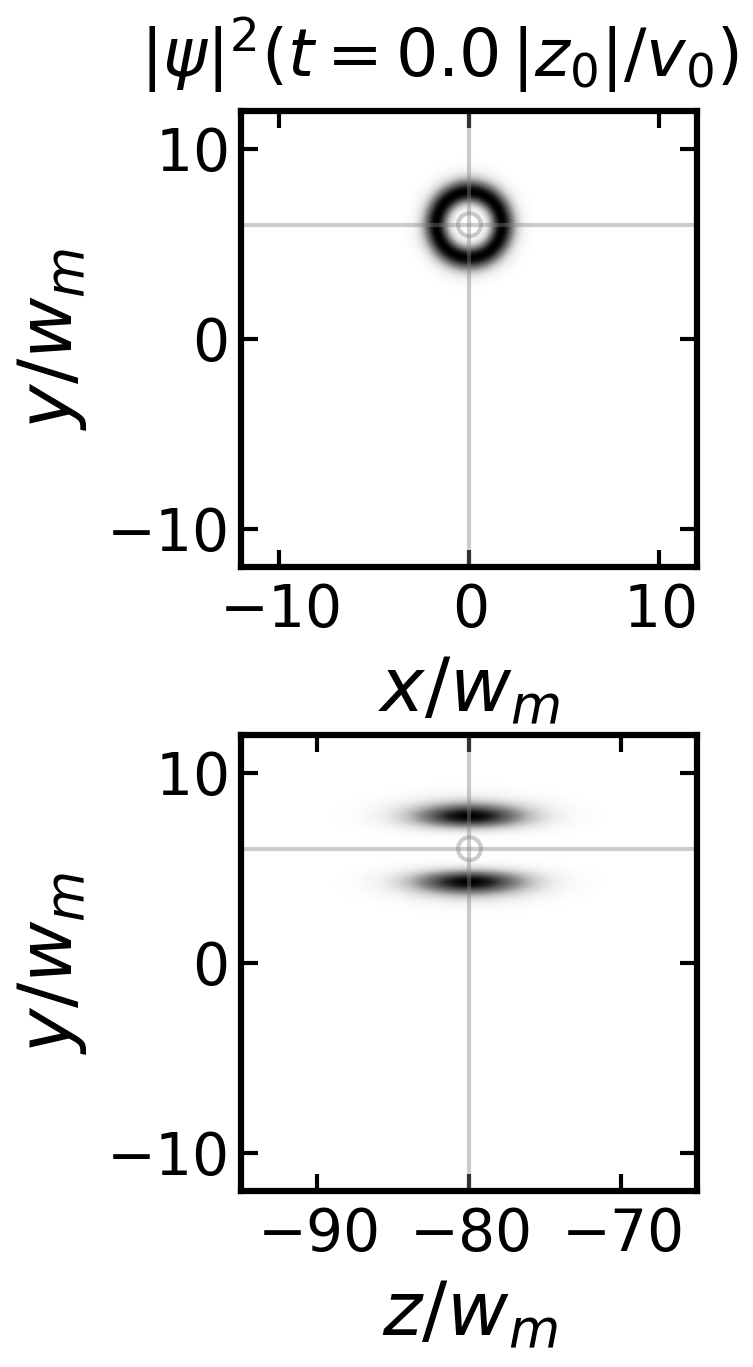

In [ ]:
def plot_psi_v7(psi, pos, t, zmin=-1, zmax=+1):
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": "Dejavu Sans",
        "mathtext.fontset": "dejavusans",
        "font.size": 11, "axes.linewidth": 1.5,
        "figure.dpi": 300, "figure.titlesize": 24,
        "axes.labelsize": 18, "axes.titlesize": 20,
        "xtick.minor.visible": False, "ytick.minor.visible": False,
        "xtick.major.size": 4, "ytick.major.size": 4,
        "xtick.labelsize": 14, "ytick.labelsize": 14,
        "xtick.direction": "in", "ytick.direction": "in",
        "axes.unicode_minus": False, "axes.formatter.use_mathtext": True,
        "legend.frameon": False, "legend.fontsize": 14,
    })
    xnode = int((pos[0] - x0) / dx) % Nx
    znode = int((pos[2] - z0) / dz) % Nz
    Z_x0 = Z[xnode, :, :]
    Y_x0 = Y[xnode, :, :]
    X_z0 = X[:, :, znode]
    Y_z0 = Y[:, :, znode]
    den_x0 = np.abs(psi[xnode, :, :])**2
    den_z0 = np.abs(psi[:, :, znode])**2
    fig = plt.figure(figsize=(2, 4), dpi=300)
    v0 = pz / m
    suptitle = r"$|\psi|^2(t={%.1f}\,|z_0|/v_0)$" % (t * v0/d0)
    fig.suptitle(suptitle, fontsize=16)

    plt.axes([0.1, 0.52, 0.9, 0.38])
    plt.gca().set_aspect('equal', adjustable='box')
    plt.pcolormesh(X_z0/wm, Y_z0/wm, den_z0, shading='gouraud', cmap='Greys')
    plt.xlim(-12,+12)#([-Lx/2/wm, Lx/2/wm])
    plt.ylim(-12,+12)#([-Ly/2/wm, Ly/2/wm])
    plt.xlabel(r"$x/w_m$", loc='center')
    plt.ylabel(r"$y/w_m$", loc='center')
    # plt.gca().set_yticklabels([])
    plt.scatter(x=pos[0]/wm, y=pos[1]/wm, s=30, marker='o',
                edgecolors='0.5', alpha=0.4, facecolors='none')
    plt.vlines(x=pos[0]/wm, ymin=-12, ymax=+12,
               color='0.5', alpha=0.4, linestyle='solid', linewidth=1)
    plt.hlines(y=pos[1]/wm, xmin=-12, xmax=+12,
               color='0.5', alpha=0.4, linestyle='solid', linewidth=1)

    plt.axes([0.1, 0.0, 0.9, 0.38])
    plt.gca().set_box_aspect(1)
    plt.pcolormesh(Z_x0/wm, Y_x0/wm, den_x0, shading='gouraud', cmap='Greys')
    plt.xlim([zmin*Lz/2/wm, zmax*Lz/2/wm])#([-Lz/2/wm, Lz/2/wm])
    plt.ylim(-12,+12)#([-Ly/2/wm, Ly/2/wm])
    plt.ylabel(r"$y/w_m$", loc='center')
    # plt.gca().set_yticklabels([])
    plt.xlabel(r"$z/w_m$", loc='center')
    plt.scatter(x=pos[2]/wm, y=pos[1]/wm, s=30, marker='o',
                edgecolors='0.5', alpha=0.4, facecolors='none')
    plt.vlines(x=pos[2]/wm, ymin=-12, ymax=+12,
               color='0.5', alpha=0.4, linestyle='solid', linewidth=1)
    plt.hlines(y=pos[1]/wm, xmin=zmin*Lz/2/wm, xmax=zmax*Lz/2/wm,
               color='0.5', alpha=0.4, linestyle='solid', linewidth=1)

step = 0
_ = plot_psi_v7(psi=np.load(filepath(step))["Psi"],
            pos=np.load(filepath(step))["pos"],
            t=np.load(filepath(step))["t"],
            zmin=-1+0.05, zmax=-0.6-0.05)

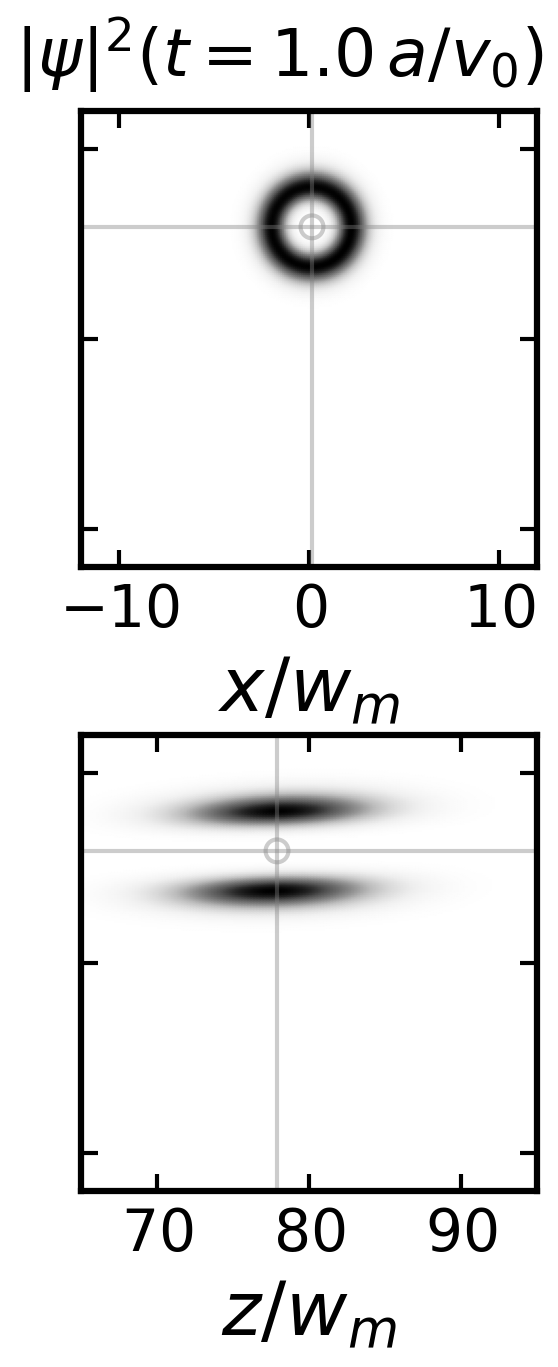

In [ ]:
def plot_psi_v7(psi, pos, t, zmin=-1, zmax=+1):
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": "Dejavu Sans",
        "mathtext.fontset": "dejavusans",
        "font.size": 11, "axes.linewidth": 1.5,
        "figure.dpi": 300, "figure.titlesize": 24,
        "axes.labelsize": 18, "axes.titlesize": 20,
        "xtick.minor.visible": False, "ytick.minor.visible": False,
        "xtick.major.size": 4, "ytick.major.size": 4,
        "xtick.labelsize": 14, "ytick.labelsize": 14,
        "xtick.direction": "in", "ytick.direction": "in",
        "axes.unicode_minus": False, "axes.formatter.use_mathtext": True,
        "legend.frameon": False, "legend.fontsize": 14,
    })
    xnode = int((pos[0] - x0) / dx) % Nx
    znode = int((pos[2] - z0) / dz) % Nz
    Z_x0 = Z[xnode, :, :]
    Y_x0 = Y[xnode, :, :]
    X_z0 = X[:, :, znode]
    Y_z0 = Y[:, :, znode]
    den_x0 = np.abs(psi[xnode, :, :])**2
    den_z0 = np.abs(psi[:, :, znode])**2
    fig = plt.figure(figsize=(2, 4), dpi=300)
    v0 = pz / m
    suptitle = r"$|\psi|^2(t={%.1f}\,a/v_0)$" % (t * v0/d0)
    fig.suptitle(suptitle, fontsize=16)

    plt.axes([0.1, 0.52, 0.9, 0.38])
    plt.gca().set_aspect('equal', adjustable='box')
    plt.pcolormesh(X_z0/wm, Y_z0/wm, den_z0, shading='gouraud', cmap='Greys')
    plt.xlim(-12,+12)#([-Lx/2/wm, Lx/2/wm])
    plt.ylim(-12,+12)#([-Ly/2/wm, Ly/2/wm])
    plt.xlabel(r"$x/w_m$", loc='center')
    # plt.ylabel(r"$y/w_m$", loc='center')
    plt.gca().set_yticklabels([])
    plt.scatter(x=pos[0]/wm, y=pos[1]/wm, s=30, marker='o',
                edgecolors='0.5', alpha=0.4, facecolors='none')
    plt.vlines(x=pos[0]/wm, ymin=-12, ymax=+12,
               color='0.5', alpha=0.4, linestyle='solid', linewidth=1)
    plt.hlines(y=pos[1]/wm, xmin=-12, xmax=+12,
               color='0.5', alpha=0.4, linestyle='solid', linewidth=1)

    plt.axes([0.1, 0.0, 0.9, 0.38])
    plt.gca().set_box_aspect(1)
    plt.pcolormesh(Z_x0/wm, Y_x0/wm, den_x0, shading='gouraud', cmap='Greys')
    plt.xlim([zmin*Lz/2/wm, zmax*Lz/2/wm])#([-Lz/2/wm, Lz/2/wm])
    plt.ylim(-12,+12)#([-Ly/2/wm, Ly/2/wm])
    # plt.ylabel(r"$y/w_m$", loc='center')
    plt.gca().set_yticklabels([])
    plt.xlabel(r"$z/w_m$", loc='center')
    plt.scatter(x=pos[2]/wm, y=pos[1]/wm, s=30, marker='o',
                edgecolors='0.5', alpha=0.4, facecolors='none')
    plt.vlines(x=pos[2]/wm, ymin=-12, ymax=+12,
               color='0.5', alpha=0.4, linestyle='solid', linewidth=1)
    plt.hlines(y=pos[1]/wm, xmin=zmin*Lz/2/wm, xmax=zmax*Lz/2/wm,
               color='0.5', alpha=0.4, linestyle='solid', linewidth=1)

step = 100
_ = plot_psi_v7(psi=np.load(filepath(step))["Psi"],
            pos=np.load(filepath(step))["pos"],
            t=np.load(filepath(step))["t"],
            zmin=+0.6+0.05, zmax=+1.0-0.05)